In [14]:
import os, sys
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score, KFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

In [15]:
df = pd.read_csv('../../data/banknote_authentication.csv')

df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

In [16]:
X = df.drop('class', axis=1)
Y = df['class']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

In [17]:
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=X.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=X.columns)

In [18]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

In [19]:
feature_selection = {
    'LR': X.columns.tolist(),
    'LDA': X.columns.tolist(),
    'DTC': X.columns.tolist(),
    'RD': X.columns.tolist(),
    'KNC': X.columns.tolist(),
    'GNB': X.columns.tolist(),
    'NN': X.columns.tolist(),
    'BG': X.columns.tolist(),
    'NB': X.columns.tolist(),
    'SVM': X.columns.tolist()
}



# 6. Đánh giá và lựa chọn mô hình học máy có giám sát

In [20]:
def check_model(name, model, X, Y, names, results, scoring):
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X[feature_selection[name]], Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = scoring.title()+" %s: %.3f%% (%.3f%%)"%(name, cv_results.mean()*100, cv_results.std()*100)
    print(msg)

Accuracy LR: 98.257% (0.533%)
Accuracy LDA: 97.494% (0.438%)
Accuracy DTC: 98.258% (0.799%)
Accuracy RD: 99.346% (0.637%)
Accuracy KNC: 99.673% (0.437%)
Accuracy NB: 83.549% (0.976%)
Accuracy SVM: 99.673% (0.437%)
Accuracy NN: 100.000% (0.000%)
Accuracy BG: 99.346% (0.637%)


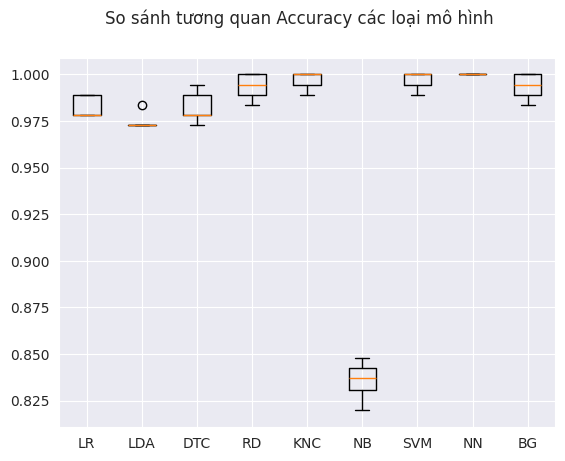

Precision LR: 96.510% (0.993%)
Precision LDA: 94.759% (0.789%)
Precision DTC: 97.855% (0.826%)
Precision RD: 99.099% (1.311%)
Precision KNC: 99.545% (0.909%)
Precision NB: 83.684% (1.571%)
Precision SVM: 99.318% (0.909%)
Precision NN: 100.000% (0.000%)
Precision BG: 99.099% (1.311%)


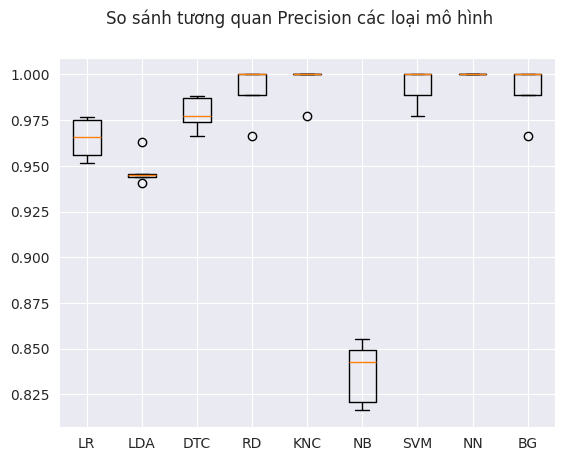

Recall LR: 99.767% (0.465%)
Recall LDA: 100.000% (0.000%)
Recall DTC: 98.280% (1.288%)
Recall RD: 99.494% (1.013%)
Recall KNC: 99.770% (0.460%)
Recall NB: 78.926% (3.513%)
Recall SVM: 100.000% (0.000%)
Recall NN: 100.000% (0.000%)
Recall BG: 99.494% (1.013%)


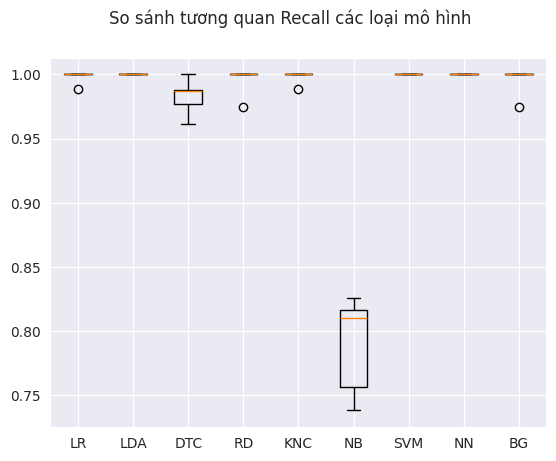

F1 LR: 98.109% (0.553%)
F1 LDA: 97.307% (0.414%)
F1 DTC: 98.179% (0.896%)
F1 RD: 99.286% (0.687%)
F1 KNC: 99.655% (0.460%)
F1 NB: 81.170% (1.637%)
F1 SVM: 99.656% (0.459%)
F1 NN: 100.000% (0.000%)
F1 BG: 99.286% (0.687%)


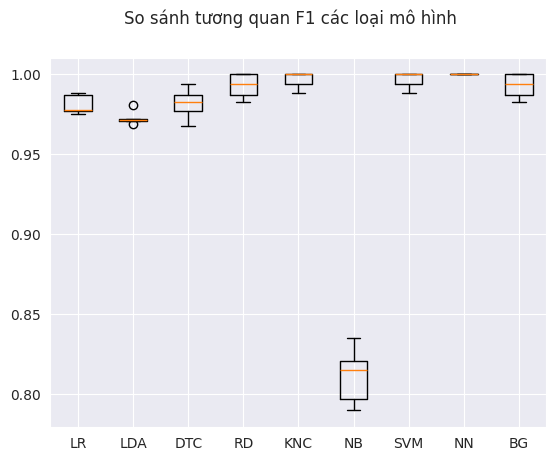

In [21]:
results = []
names = []
scorings = ['accuracy','precision','recall','f1']

for scoring in scorings:
    check_model('LR', LogisticRegression(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('LDA', LinearDiscriminantAnalysis(), x_train, y_train, names, results, scoring)
    check_model('DTC', DecisionTreeClassifier(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('RD', RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('KNC', KNeighborsClassifier(n_neighbors=10), x_train, y_train, names, results, scoring)
    check_model('NB', GaussianNB(), x_train, y_train, names, results, scoring)
    check_model('SVM', SVC(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('NN', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500), x_train, y_train, names, results, scoring)
    check_model('BG', GradientBoostingClassifier(), x_train, y_train, names, results, scoring)

    fig = plt.figure()
    fig.suptitle(f'So sánh tương quan {scoring.title()} các loại mô hình')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

    results = []
    names = []

In [22]:
model = DecisionTreeClassifier(class_weight=class_weights_dict)

supervied_features = x_train[feature_selection['DTC']]
supervied_target = y_train

model.fit(supervied_features, supervied_target)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
predictions = model.predict(x_test[feature_selection['DTC']])

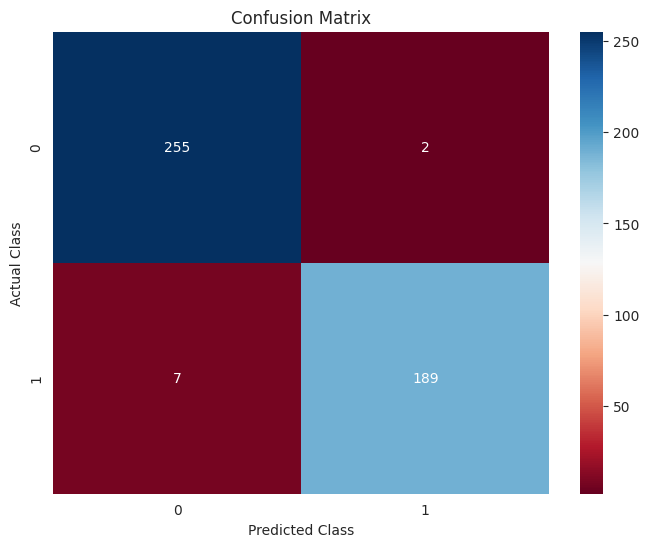

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       257
           1       0.99      0.96      0.98       196

    accuracy                           0.98       453
   macro avg       0.98      0.98      0.98       453
weighted avg       0.98      0.98      0.98       453



In [24]:
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='RdBu')
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()

print(classification_report(y_test, predictions))

In [25]:
def check_result(pred):
    return "Y" if pred == 1 else "N"

def check_output(stt, model, X_test, Y_test):
    print(f"Lần thứ {stt}: ")
    indx = rd.randint(0, X_test.shape[0] - 1)

    sample = X_test.iloc[indx:indx+1]
    y_predict = model.predict(sample)

    Y_check = check_result(Y_test.iloc[indx])

    print('True:', Y_check)
    print('Predicted:', check_result(y_predict[0]))
    print("----------------------------")

    return Y_check == check_result(y_predict[0])

In [26]:
n_check = 10
solandung = 0

for i in range(n_check):
    if check_output(i+1, model, x_test[feature_selection['DTC']], y_test):
        solandung += 1

print(f"Số lần dự đoán đúng: {solandung} chiếm khoảng {(solandung/n_check)*100}%")


Lần thứ 1: 
True: Y
Predicted: Y
----------------------------
Lần thứ 2: 
True: N
Predicted: N
----------------------------
Lần thứ 3: 
True: N
Predicted: N
----------------------------
Lần thứ 4: 
True: Y
Predicted: Y
----------------------------
Lần thứ 5: 
True: N
Predicted: N
----------------------------
Lần thứ 6: 
True: Y
Predicted: Y
----------------------------
Lần thứ 7: 
True: Y
Predicted: Y
----------------------------
Lần thứ 8: 
True: N
Predicted: N
----------------------------
Lần thứ 9: 
True: N
Predicted: N
----------------------------
Lần thứ 10: 
True: N
Predicted: N
----------------------------
Số lần dự đoán đúng: 10 chiếm khoảng 100.0%


In [27]:
solandung = 0

for indx in range(len(x_test)):
    sample = x_test[feature_selection['DTC']].iloc[indx:indx+1]
    y_predict = model.predict(sample)

    Y_check = check_result(y_test.iloc[indx])

    if Y_check == check_result(y_predict[0]):
        solandung += 1

print(f"Số lần dự đoán đúng: {solandung} chiếm khoảng {(solandung/len(x_test))*100}%")

Số lần dự đoán đúng: 444 chiếm khoảng 98.01324503311258%
